In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
import sys

In [6]:
df_electron = pd.read_csv(""../../Data_Separated/Bias/electronBias.csv"")
df_muon = pd.read_csv(""../../Data_Separated/Bias/muonBias.csv"")

df_electron_clean = df_electron[
    (df_electron['topo_cluster_eta'] != -10.0) &
    (df_electron['topo_cluster_pt'] != -1.0) &
    (df_electron['topo_cluster_phi'] != -10.0) &
    (df_electron['topo_cluster_EM_prob'] != -1.0) &
    (df_electron['pt_ratio'] != -1.0) &
    (df_electron['topo_cluster_lambda'] != -1.0) &
    (df_electron['topo_cluster_lambda2'] != -1.0)
]

df_muon_clean = df_muon[
    (df_muon['topo_cluster_eta'] != -10.0) &
    (df_muon['topo_cluster_pt'] != -1.0) &
    (df_muon['topo_cluster_phi'] != -10.0) &
    (df_muon['topo_cluster_EM_prob'] != -1.0) &
    (df_muon['pt_ratio'] != -1.0) &
    (df_muon['topo_cluster_lambda'] != -1.0) &
    (df_muon['topo_cluster_lambda2'] != -1.0)
]

df_electron_clean['label'] = 1  # Electrons = 1
df_muon_clean['label'] = 0

df_full = pd.concat([df_electron_clean, df_muon_clean], ignore_index=True)

C:\Users\qmiko\AppData\Local\Temp\ipykernel_12520\641230338.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_electron_clean['label'] = 1  # Electrons = 1
C:\Users\qmiko\AppData\Local\Temp\ipykernel_12520\641230338.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_muon_clean['label'] = 0


In [8]:
feature_columns = [col for col in df_full.columns if col not in ['event', 'track_idx', 'label']]
x_data = df_full[feature_columns].values
y_data = df_full['label'].values

test_size = 0.2
x_train, x_val, y_train, y_val = train_test_split(x_data, y_data, test_size = test_size)

scaler = StandardScaler()
x_train= scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

In [18]:
clf = RandomForestClassifier(max_depth=100, n_estimators=1500, random_state=0, n_jobs=-1, min_samples_leaf=3, min_samples_split=5, max_features=5)
clf.fit(x_train, y_train)

,n_estimators,1500
,criterion,'gini'
,max_depth,100
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
pred = clf.predict(x_val)
acc = np.mean(pred == y_val)

Najlepszy próg: 0.393


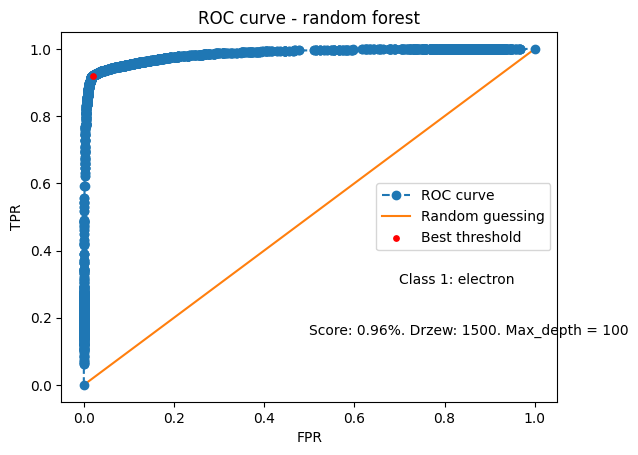

In [82]:

prob = clf.predict_proba(x_val)
fpr, tpr, thresholds = metrics.roc_curve(y_val, prob[:,1])  # dla 1 czyli mionelektrony
plt.plot(fpr, tpr, 'o--', zorder = 1, label='ROC curve')
plt.plot([0,1],[0,1], zorder=0, label = 'Random guessing')
plt.title("ROC curve - random forest")
plt.text(0.7,0.3, 'Class 1: electron')
plt.text(0.5,0.15, f'Score: {acc:.2f}%. Drzew: 1500. Max_depth = 100')

J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print(f"Najlepszy próg: {best_thresh:.3f}")

plt.scatter(fpr[ix], tpr[ix], c='red', s=15, zorder =2, label = 'Best threshold')
plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.savefig(r"C:\Users\qmiko\Desktop\cern\Plots_ml\Forest_roc.png")
plt.show()

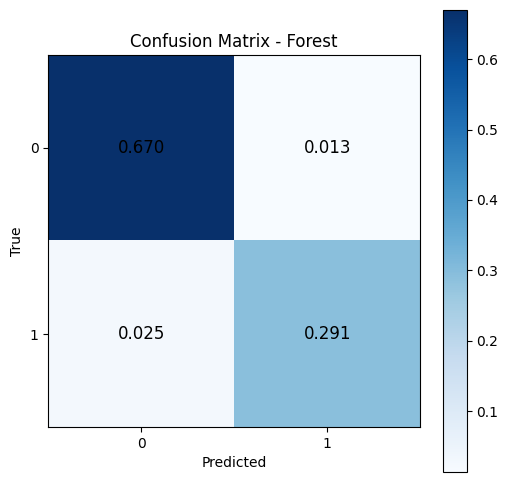

In [81]:
true = y_val
pred = clf.predict_proba(x_val)
pred_th = (pred[:,1] >= best_thresh).astype(int) #1 to elektorn i to jest jako Positive
mat = metrics.confusion_matrix(true, pred_th)
mat = mat/np.sum(mat)

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(mat, cmap='Blues') # kolorowa mapa


# dodanie kolorowego paska obok
cbar = ax.figure.colorbar(im, ax=ax)


# podpisy osi
classes = [0, 1]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Forest")


# dopisywanie wartości w komórkach
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", color="black", fontsize=12)

plt.savefig(r"C:\Users\qmiko\Desktop\cern\Plots_ml\Forest_matrix.png")
plt.show()